# Flight Price Analysis

#### FEATURES
The various features of the cleaned dataset are explained below:
1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10)Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.
11) Price: Target variable stores information of the ticket price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('flight_price.xlsx')

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
#Information Of The Data:-
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.isnull().value_counts()

Airline  Date_of_Journey  Source  Destination  Route  Dep_Time  Arrival_Time  Duration  Total_Stops  Additional_Info  Price
False    False            False   False        False  False     False         False     False        False            False    10682
                                               True   False     False         False     True         False            False        1
Name: count, dtype: int64

In [6]:
df['Date'] = df['Date_of_Journey'].str.split('/').str[0]
df['Month'] = df['Date_of_Journey'].str.split('/').str[1]
df['Year'] = df['Date_of_Journey'].str.split('/').str[2]

In [7]:
## here the Date,month,year are in object Datatype
#we have to convert them into integer
df['Date']=df['Date'].astype(int)
df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].astype(int)


In [8]:
#Drop Date Of Journey
df.drop('Date_of_Journey',axis=1,inplace=True)

In [9]:
df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x: x.split(' ')[0])

In [10]:
df['Arrival_hour']=df['Arrival_Time'].str.split(':').str[0]
df['Arrival_minutes']=df['Arrival_Time'].str.split(':').str[1]


In [11]:
df.drop('Arrival_Time',axis=1,inplace=True)

In [12]:
df['Arrival_hour'] = df['Arrival_hour'].astype(int)
df['Arrival_minutes'] = df['Arrival_minutes'].astype(int)

In [13]:
df['Departure_hour']=df['Dep_Time'].str.split(':').str[0]
df['Departure_minutes']=df['Dep_Time'].str.split(':').str[1]

In [14]:
df.drop('Dep_Time',axis=1,inplace=True)

In [15]:
df['Departure_hour'] = df['Departure_hour'].astype(int)
df['Departure_minutes'] = df['Departure_minutes'].astype(int)

In [16]:
df.isnull().sum()

Airline              0
Source               0
Destination          0
Route                1
Duration             0
Total_Stops          1
Additional_Info      0
Price                0
Date                 0
Month                0
Year                 0
Arrival_hour         0
Arrival_minutes      0
Departure_hour       0
Departure_minutes    0
dtype: int64

In [17]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [18]:
df['Total_Stops'].mode()

0    1 stop
Name: Total_Stops, dtype: object

In [38]:
df['Total_Stops'] = df['Total_Stops'].replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,np.nan:1})

In [20]:
df['Total_Stops'] = df['Total_Stops'].astype(int)

In [21]:
df.drop('Route',axis=1,inplace=True)

In [22]:
df['Duration_hours'] = df['Duration'].str.extract(r'(\d+)h')
df['Duration_hours'] = df['Duration_hours'].fillna(0)
df['Duration_hours'] = df['Duration'].str.split(' ').str[0].str.split('h').str[0]
df['Duration_minutes']= df['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [23]:
df['Duration_minutes'] = df['Duration_minutes'].replace({np.nan:0,'5m':5})

In [24]:
df.drop('Duration',axis=1,inplace = True)

In [25]:
df['Duration_hours'] = pd.to_numeric(df['Duration_hours'], errors='coerce').fillna(0).astype(int)
df['Duration_minutes'] = pd.to_numeric(
    df['Duration_minutes'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
).fillna(0).astype(int)
df['Duration_minutes']=df['Duration_minutes'].astype(int)

In [26]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_hour,Arrival_minutes,Departure_hour,Departure_minutes,Duration_hours,Duration_minutes
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,21,35,16,50,4,45


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline            10683 non-null  object
 1   Source             10683 non-null  object
 2   Destination        10683 non-null  object
 3   Total_Stops        10683 non-null  int64 
 4   Additional_Info    10683 non-null  object
 5   Price              10683 non-null  int64 
 6   Date               10683 non-null  int64 
 7   Month              10683 non-null  int64 
 8   Year               10683 non-null  int64 
 9   Arrival_hour       10683 non-null  int64 
 10  Arrival_minutes    10683 non-null  int64 
 11  Departure_hour     10683 non-null  int64 
 12  Departure_minutes  10683 non-null  int64 
 13  Duration_hours     10683 non-null  int64 
 14  Duration_minutes   10683 non-null  int64 
dtypes: int64(11), object(4)
memory usage: 1.2+ MB


In [28]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [29]:
df['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [30]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

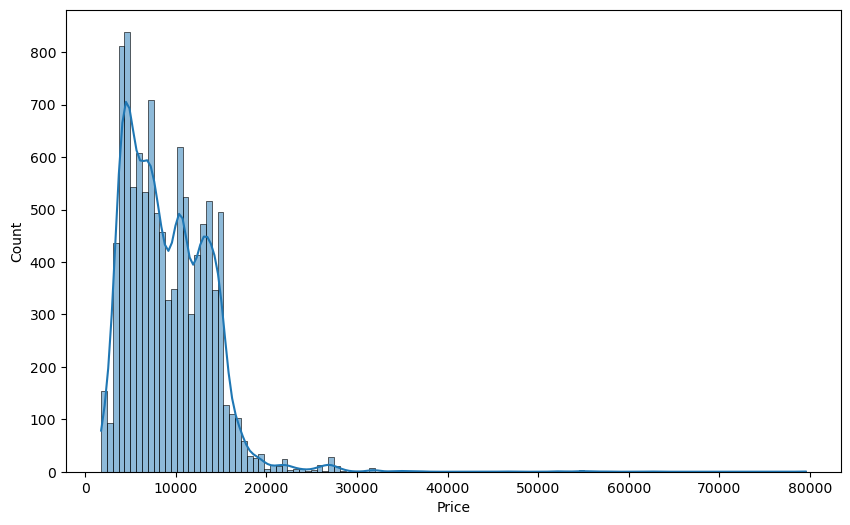

In [31]:

plt.figure(figsize=(10,6))
sns.histplot(df['Price'], kde=True)

plt.show()

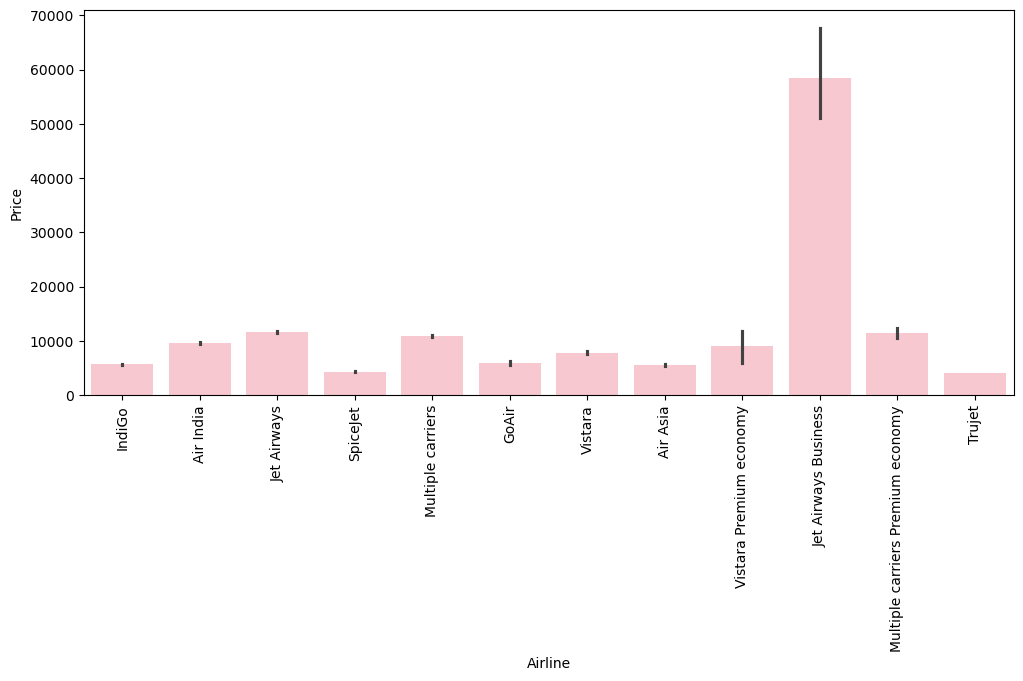

In [32]:
plt.figure(figsize=(12,5))
sns.barplot(x='Airline', y='Price', data=df,color='pink')
plt.xticks(rotation=90)
plt.show()

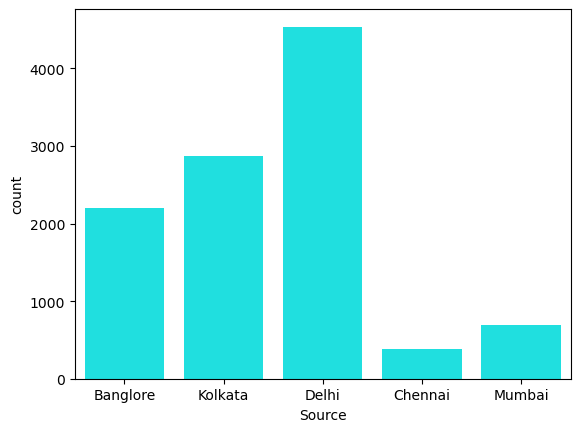

In [33]:
sns.countplot(x='Source', data=df,color='cyan')
plt.show()

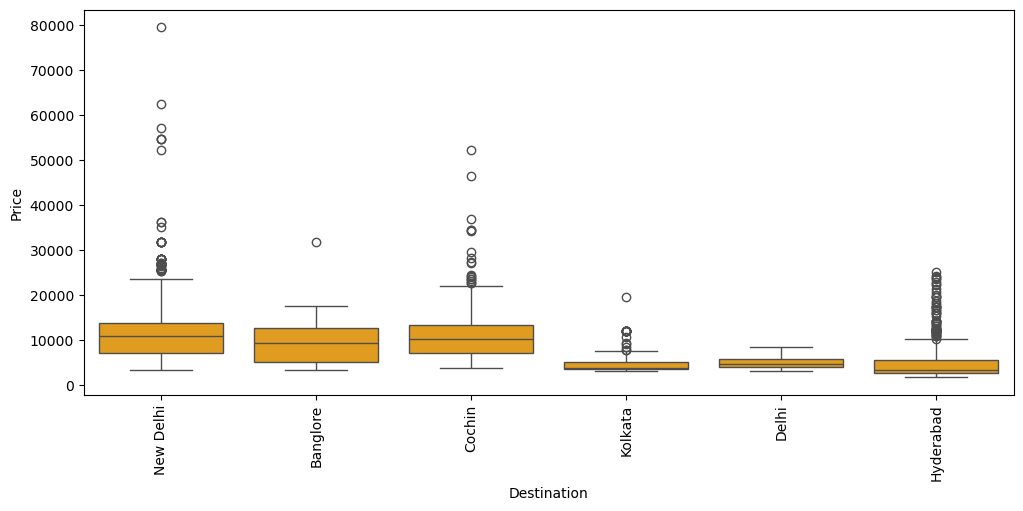

In [34]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Destination', y='Price', data=df,color='orange')
plt.xticks(rotation=90)
plt.show()

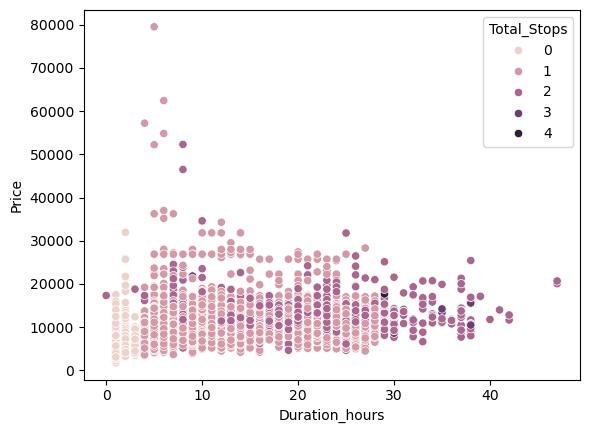

In [35]:
sns.scatterplot(
    x='Duration_hours',
    y='Price',hue='Total_Stops',
    data=df
)
plt.show()

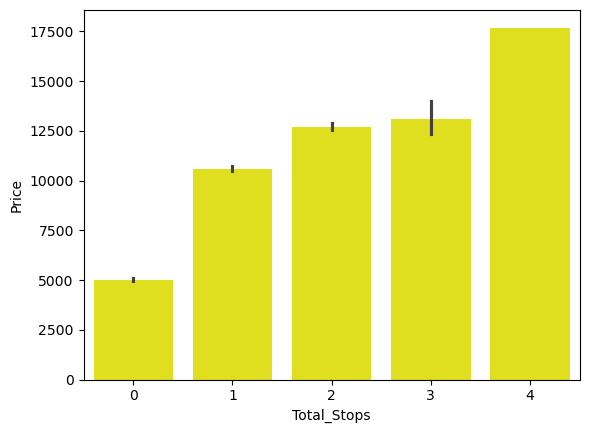

In [36]:
sns.barplot(x='Total_Stops', y='Price', data=df,color='yellow')
plt.show()

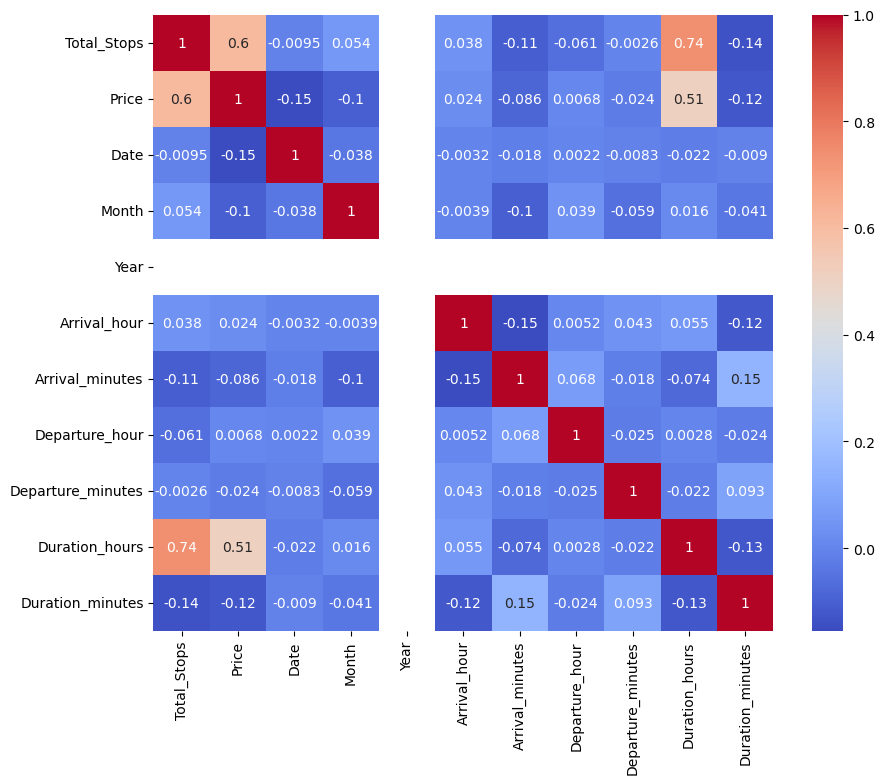

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### CONCLUSIION :-

1. Most flight prices are concentrated between ₹3,000–₹15,000.
2. Airline choice significantly impacts ticket pricing.
3. Delhi is the busiest source city in the dataset.
4. Flights to New Delhi and Cochin tend to be more expensive.
5. Flight duration positively affects ticket prices.
6. Ticket prices increase with the number of stops.
7. Total Stops and Duration Hours are the strongest numerical predictors of price.